# Introduction to Linear Algebra for Sensorimotor Control
## A Hands-On Tutorial for Movement Neuroscience Graduate Students

---

**Why this tutorial?**  
Linear algebra is the mathematical backbone of almost everything in computational sensorimotor control:

- **Coordinate transformations:** rotating between joint space, hand space, and world coordinates
- **Equations of motion:** Newton–Euler dynamics as $M\ddot{q} + C\dot{q} + G = \tau$
- **Muscle synergies:** extracting low-dimensional patterns from high-dimensional EMG via NMF or PCA
- **State-space models:** representing linear dynamical systems as $\dot{x} = Ax + Bu$
- **Regression & model fitting:** least-squares solutions to $Ax = b$
- **Dimensionality reduction:** PCA, SVD, and eigendecomposition of neural population data

This notebook teaches the essential linear algebra operations in Python/NumPy, with every concept tied to a concrete sensorimotor control application.

**Prerequisites:** Python Basics (L0), NumPy (L1), Matplotlib (L3).  
**Environment:** Google Colab (recommended) or Jupyter Notebook.

---

## Table of Contents

**Part I — Vectors and Matrices**
1. [Vectors — Position, Velocity, Force](#1)
2. [Dot Product and Projections](#2)
3. [Cross Product (3-D only)](#3)
4. [Matrices — Creating and Inspecting](#4)
5. [Matrix Multiplication](#5)

**Part II — Transformations**
6. [Coordinate Transformations — Rotation Matrices](#6)
7. [Homogeneous Transformations (Translation + Rotation)](#7)

**Part III — Solving Systems and Decompositions**
8. [Solving Linear Systems: $Ax = b$](#8)
9. [Matrix Inverse and Pseudo-Inverse](#9)
10. [Determinant and Rank](#10)
11. [Eigenvalues and Eigenvectors](#11)
12. [Singular Value Decomposition (SVD)](#12)

**Part IV — Applications in Sensorimotor Control**
13. [Least-Squares Regression](#13)
14. [PCA — Dimensionality Reduction](#14)
15. [State-Space Models — Linear Dynamical Systems](#15)

**Part V — Practice**
16. [Exercises](#16)
17. [Summary & Further Reading](#17)

In [1]:
# ---- Setup ----

import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, det, eig, svd, norm, matrix_rank, solve, lstsq

---
# Part I — Vectors and Matrices

## 1. Vectors — Position, Velocity, Force <a id='1'></a>

In sensorimotor control, a **vector** is the natural representation for any quantity with magnitude and direction: hand position, joint velocities, muscle forces, EMG patterns across muscles.

In NumPy, vectors are just 1-D arrays.

In [2]:
# ---- Creating vectors ----

# Hand position in 2-D workspace (x, y) in cm:
hand_pos = np.array([15.0, 22.0])

# Joint angles (shoulder, elbow) in radians:
joint_angles = np.array([0.78, 1.57])  # ~45°, ~90°

# EMG activation pattern across 8 muscles:
emg = np.array([0.12, 0.85, 0.34, 0.05, 0.92, 0.41, 0.08, 0.67])

print(f"Hand position: {hand_pos}")
print(f"Joint angles:  {joint_angles}")
print(f"EMG pattern:   {emg}")

Hand position: [15. 22.]
Joint angles:  [0.78 1.57]
EMG pattern:   [0.12 0.85 0.34 0.05 0.92 0.41 0.08 0.67]


In [3]:
# ---- Vector operations ----

# Addition: displacement from one position to another
start = np.array([10.0, 15.0])
displacement = np.array([5.0, 7.0])
end = start + displacement
print(f"Start + Displacement = End: {start} + {displacement} = {end}")

# Scalar multiplication: scaling a force vector
force_direction = np.array([0.6, 0.8])    # Unit direction
force_magnitude = 50.0                     # Newtons
force_vector = force_magnitude * force_direction
print(f"Force vector: {force_vector} N")

# Magnitude (Euclidean norm): distance or speed
distance = norm(displacement)
print(f"Distance: {distance:.2f} cm")

# Unit vector: direction without magnitude
unit = displacement / norm(displacement)
print(f"Unit vector: {unit} (norm = {norm(unit):.4f})")

Start + Displacement = End: [10. 15.] + [5. 7.] = [15. 22.]
Force vector: [30. 40.] N
Distance: 8.60 cm
Unit vector: [0.58123819 0.81373347] (norm = 1.0000)


---
## 2. Dot Product and Projections <a id='2'></a>

The **dot product** measures how much two vectors point in the same direction. It's used constantly in biomechanics (work = force · displacement) and in neural coding (similarity between tuning curves).

$$\mathbf{a} \cdot \mathbf{b} = \sum_i a_i b_i = \|a\| \|b\| \cos\theta$$

In [4]:
# ---- Dot product ----

force = np.array([30.0, 40.0])       # Force vector (N)
displacement = np.array([2.0, 0.0])  # Displacement vector (m)

# Mechanical work = force · displacement
work = np.dot(force, displacement)
print(f"Work = F · d = {work} Joules")

# Angle between two vectors
cos_theta = np.dot(force, displacement) / (norm(force) * norm(displacement))
angle_deg = np.degrees(np.arccos(np.clip(cos_theta, -1, 1)))
print(f"Angle between F and d: {angle_deg:.1f}°")

Work = F · d = 60.0 Joules
Angle between F and d: 53.1°


Force along movement: 30.0 N
Parallel component:      [30.  0.]
Perpendicular component: [ 0. 40.]


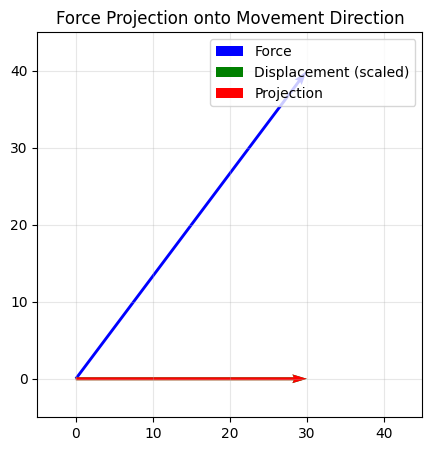

In [5]:
# ---- Projection: decompose a vector along a direction ----
# How much of the force acts along the direction of movement?

d_hat = displacement / norm(displacement)   # Unit vector in displacement direction

# Scalar projection:
force_along = np.dot(force, d_hat)
print(f"Force along movement: {force_along:.1f} N")

# Vector projection:
force_proj = force_along * d_hat
force_perp = force - force_proj
print(f"Parallel component:      {force_proj}")
print(f"Perpendicular component: {force_perp}")

# Visualize
plt.figure(figsize=(6, 5))
origin = [0, 0]
plt.quiver(*origin, *force, angles='xy', scale_units='xy', scale=1, color='blue', label='Force')
plt.quiver(*origin, *displacement*15, angles='xy', scale_units='xy', scale=1, color='green', label='Displacement (scaled)')
plt.quiver(*origin, *force_proj, angles='xy', scale_units='xy', scale=1, color='red', linewidth=2, label='Projection')
plt.xlim(-5, 45)
plt.ylim(-5, 45)
plt.gca().set_aspect('equal')
plt.legend()
plt.grid(True, alpha=0.3)
plt.title('Force Projection onto Movement Direction')
plt.show()

---
## 3. Cross Product (3-D only) <a id='3'></a>

The **cross product** gives a vector perpendicular to both inputs. Its magnitude equals the area of the parallelogram formed by the two vectors.

**Neuroscience use:** Computing joint torques from moment arms and forces ($\tau = r \times F$).

In [6]:
# ---- Cross product: torque = moment_arm × force ----

moment_arm = np.array([0.0, 0.3, 0.0])   # 30 cm along y-axis (forearm)
force_3d = np.array([0.0, 0.0, -50.0])   # 50 N downward (gravity)

torque = np.cross(moment_arm, force_3d)
print(f"Torque = r × F = {torque} Nm")
print(f"Torque magnitude: {norm(torque):.1f} Nm")

Torque = r × F = [-15.   0.   0.] Nm
Torque magnitude: 15.0 Nm


---
## 4. Matrices — Creating and Inspecting <a id='4'></a>

A **matrix** is a 2-D array of numbers. In sensorimotor control, matrices represent transformations, system dynamics, covariance structures, and more.

| Matrix | Meaning | Example |
|---|---|---|
| Rotation matrix $R$ | Rotates coordinates between frames | Joint-to-hand transformation |
| Jacobian $J$ | Maps joint velocities to hand velocities | $\dot{x} = J \dot{q}$ |
| Mass matrix $M$ | Relates accelerations to forces | $M\ddot{q} = \tau$ |
| Covariance matrix $\Sigma$ | Describes variability structure | Endpoint error ellipses |

In [7]:
# ---- Creating matrices ----

# From a list of lists:
A = np.array([[1, 2, 3],
              [4, 5, 6]])
print(f"A =\n{A}")
print(f"Shape: {A.shape}")  # (2, 3) — 2 rows, 3 columns

# Special matrices:
I = np.eye(3)              # 3×3 identity matrix
Z = np.zeros((2, 4))      # 2×4 matrix of zeros
D = np.diag([1, 2, 3])    # Diagonal matrix

print(f"\nIdentity:\n{I}")
print(f"\nDiagonal:\n{D}")

A =
[[1 2 3]
 [4 5 6]]
Shape: (2, 3)

Identity:
[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]]

Diagonal:
[[1 0 0]
 [0 2 0]
 [0 0 3]]


In [8]:
# ---- Matrix properties ----

M = np.array([[2.0, 0.5],
              [0.5, 1.5]])  # A symmetric mass matrix

print(f"M =\n{M}")
print(f"Shape:     {M.shape}")
print(f"Transpose: \n{M.T}")
print(f"Symmetric? {np.allclose(M, M.T)}")
print(f"Trace:     {np.trace(M)}")     # Sum of diagonal elements
print(f"Frobenius norm: {norm(M):.3f}")  # Matrix "size"

M =
[[2.  0.5]
 [0.5 1.5]]
Shape:     (2, 2)
Transpose: 
[[2.  0.5]
 [0.5 1.5]]
Symmetric? True
Trace:     3.5
Frobenius norm: 2.598


---
## 5. Matrix Multiplication <a id='5'></a>

Matrix multiplication is the core operation in linear algebra. Remember:
- `*` does **element-wise** multiplication
- `@` or `np.dot()` does **matrix** multiplication

For $(m \times n) @ (n \times p) = (m \times p)$, the inner dimensions must match.

In [9]:
# ---- Matrix × matrix ----

A = np.array([[1, 2],
              [3, 4]])
B = np.array([[5, 6],
              [7, 8]])

print(f"A * B (element-wise):\n{A * B}")
print(f"\nA @ B (matrix multiply):\n{A @ B}")

A * B (element-wise):
[[ 5 12]
 [21 32]]

A @ B (matrix multiply):
[[19 22]
 [43 50]]


In [10]:
# ---- Matrix × vector ----
# This is the fundamental operation: transforming a vector.

# Example: Jacobian maps joint velocities to hand velocities
# dx/dt = J * dq/dt

J = np.array([[0.3, 0.2],     # Jacobian (2×2 for a 2-link arm)
              [0.4, 0.1]])

q_dot = np.array([1.0, 0.5])  # Joint velocities (rad/s)

x_dot = J @ q_dot             # Hand velocity (m/s)
print(f"Joint velocities: {q_dot} rad/s")
print(f"Hand velocity:    {x_dot} m/s")
print(f"Hand speed:       {norm(x_dot):.3f} m/s")

Joint velocities: [1.  0.5] rad/s
Hand velocity:    [0.4  0.45] m/s
Hand speed:       0.602 m/s


---
# Part II — Transformations

## 6. Coordinate Transformations — Rotation Matrices <a id='6'></a>

A **2-D rotation matrix** rotates a vector by angle $\theta$:

$$R(\theta) = \begin{pmatrix} \cos\theta & -\sin\theta \\ \sin\theta & \cos\theta \end{pmatrix}$$

**Neuroscience use:** Transforming coordinates between reference frames (body frame to world frame), rotating force fields in visuomotor adaptation experiments.

In [11]:
# ---- 2-D rotation matrix ----

def rotation_matrix_2d(theta_deg):
    """Create a 2-D rotation matrix for angle theta (in degrees)."""
    theta = np.radians(theta_deg)
    return np.array([[np.cos(theta), -np.sin(theta)],
                     [np.sin(theta),  np.cos(theta)]])

# Rotate a hand position by 45 degrees
R = rotation_matrix_2d(45)
original = np.array([10.0, 0.0])    # Pointing along x-axis
rotated = R @ original

print(f"Original: {original}")
print(f"Rotated (45°): {rotated.round(3)}")
print(f"Length preserved? {norm(original):.3f} → {norm(rotated):.3f}")

Original: [10.  0.]
Rotated (45°): [7.071 7.071]
Length preserved? 10.000 → 10.000


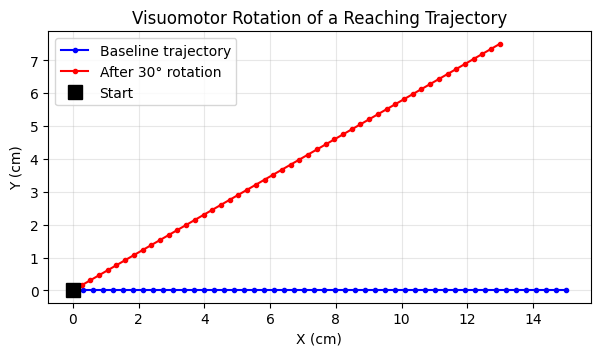

In [12]:
# ---- Visualize: rotate a reaching trajectory ----

# Generate a straight reaching trajectory (baseline)
t = np.linspace(0, 1, 50)
x_traj = 15 * t
y_traj = np.zeros_like(t)
baseline = np.column_stack([x_traj, y_traj])  # (50, 2)

# Apply a 30° visuomotor rotation (like in adaptation experiments)
R30 = rotation_matrix_2d(30)
rotated_traj = (R30 @ baseline.T).T  # Rotate each point

plt.figure(figsize=(7, 7))
plt.plot(baseline[:, 0], baseline[:, 1], 'b-o', markersize=3, label='Baseline trajectory')
plt.plot(rotated_traj[:, 0], rotated_traj[:, 1], 'r-o', markersize=3, label='After 30° rotation')
plt.plot(0, 0, 'ks', markersize=10, label='Start')
plt.gca().set_aspect('equal')
plt.xlabel('X (cm)')
plt.ylabel('Y (cm)')
plt.title('Visuomotor Rotation of a Reaching Trajectory')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
# ---- Key property: R^T = R^(-1) for rotation matrices ----

print(f"R @ R.T =\n{(R @ R.T).round(10)}")
print(f"\nThis is the identity matrix — the inverse of a rotation is its transpose!")
print(f"det(R) = {det(R):.6f}")  # Determinant is always 1 for a proper rotation

---
## 7. Homogeneous Transformations (Translation + Rotation) <a id='7'></a>

In robotics and biomechanics, you often need both **rotation and translation**. Homogeneous coordinates let you combine them in a single matrix multiplication:

$$T = \begin{pmatrix} R & \mathbf{d} \\ \mathbf{0} & 1 \end{pmatrix}$$

where $R$ is the rotation matrix and $\mathbf{d}$ is the translation vector.

In [13]:
# ---- Homogeneous transformation: rotate + translate ----

def homogeneous_2d(theta_deg, dx, dy):
    """Create a 2-D homogeneous transformation matrix."""
    theta = np.radians(theta_deg)
    return np.array([[np.cos(theta), -np.sin(theta), dx],
                     [np.sin(theta),  np.cos(theta), dy],
                     [0,              0,              1]])

# Example: transform from shoulder frame to elbow frame
# The elbow is 30 cm from the shoulder, shoulder angle = 45°
T_shoulder = homogeneous_2d(45, 0, 0)    # Rotate 45° at shoulder
upper_arm_length = 30  # cm

# Position of elbow in shoulder frame
elbow_local = np.array([upper_arm_length, 0, 1])  # Homogeneous coordinates
elbow_world = T_shoulder @ elbow_local

print(f"Elbow position (world frame): ({elbow_world[0]:.1f}, {elbow_world[1]:.1f}) cm")

Elbow position (world frame): (21.2, 21.2) cm


---
# Part III — Solving Systems and Decompositions

## 8. Solving Linear Systems: $Ax = b$ <a id='8'></a>

Many problems reduce to solving $Ax = b$ — finding the vector $x$ that satisfies the equation.

**Neuroscience example:** Given joint torques $\tau$ and the mass matrix $M$, find the joint accelerations: $M\ddot{q} = \tau$.

Use `np.linalg.solve(A, b)` — **never** compute `inv(A) @ b` (it's slower and less numerically stable).

In [14]:
# ---- Solve Ax = b ----

# Mass matrix for a 2-link arm:
M = np.array([[2.5, 0.8],
              [0.8, 1.2]])

# Known joint torques:
tau = np.array([10.0, 5.0])   # Nm

# Solve for joint accelerations: M * q_ddot = tau
q_ddot = solve(M, tau)

print(f"Mass matrix M:\n{M}")
print(f"Torques:       {tau} Nm")
print(f"Accelerations: {q_ddot.round(3)} rad/s²")

# Verify: M @ q_ddot should equal tau
print(f"\nVerification M @ q_ddot = {(M @ q_ddot).round(6)}")

Mass matrix M:
[[2.5 0.8]
 [0.8 1.2]]
Torques:       [10.  5.] Nm
Accelerations: [3.39  1.907] rad/s²

Verification M @ q_ddot = [10.  5.]


---
## 9. Matrix Inverse and Pseudo-Inverse <a id='9'></a>

The **inverse** $A^{-1}$ exists only for square, non-singular matrices. The **pseudo-inverse** $A^+$ works for any matrix (including non-square and rank-deficient).

| Function | When to use |
|---|---|
| `np.linalg.solve(A, b)` | Square $A$, solve $Ax=b$ (preferred) |
| `np.linalg.inv(A)` | Square $A$, need $A^{-1}$ explicitly |
| `np.linalg.pinv(A)` | Non-square or rank-deficient $A$ |
| `np.linalg.lstsq(A, b)` | Least-squares solution for overdetermined systems |

In [15]:
# ---- Inverse ----

M_inv = inv(M)
print(f"M^(-1) =\n{M_inv.round(4)}")
print(f"\nM @ M^(-1) =\n{(M @ M_inv).round(10)}")  # Should be identity

M^(-1) =
[[ 0.5085 -0.339 ]
 [-0.339   1.0593]]

M @ M^(-1) =
[[ 1.  0.]
 [-0.  1.]]


In [16]:
# ---- Pseudo-inverse: for non-square matrices ----
# Example: Jacobian transpose control — map hand forces to joint torques
# tau = J^T @ F_hand (overconstrained if more joints than hand dimensions)

J = np.array([[0.3, 0.2, 0.1],   # 2×3 Jacobian (2-D hand, 3 joints)
              [0.4, 0.1, 0.3]])

J_pinv = np.linalg.pinv(J)        # 3×2 pseudo-inverse
print(f"J shape:      {J.shape}")
print(f"J+ shape:     {J_pinv.shape}")
print(f"J @ J+ ≈ I?\n{(J @ J_pinv).round(6)}")

J shape:      (2, 3)
J+ shape:     (3, 2)
J @ J+ ≈ I?
[[ 1. -0.]
 [ 0.  1.]]


---
## 10. Determinant and Rank <a id='10'></a>

| Property | What it tells you | Neuroscience meaning |
|---|---|---|
| **Determinant** | Volume scaling factor; 0 = singular | If $\det(J) = 0$, arm is at a kinematic singularity |
| **Rank** | Number of independent rows/columns | Dimensionality of the muscle synergy space |

In [17]:
# ---- Determinant and rank ----

A = np.array([[1, 2],
              [3, 4]])
print(f"det(A) = {det(A):.1f}")          # Non-zero → invertible
print(f"rank(A) = {matrix_rank(A)}")      # 2 → full rank

# A singular (non-invertible) matrix:
B = np.array([[1, 2],
              [2, 4]])   # Row 2 = 2 × Row 1
print(f"\ndet(B) = {det(B):.1f}")        # 0 → singular!
print(f"rank(B) = {matrix_rank(B)}")      # 1 → rank deficient

det(A) = -2.0
rank(A) = 2

det(B) = 0.0
rank(B) = 1


---
## 11. Eigenvalues and Eigenvectors <a id='11'></a>

An **eigenvector** of a matrix $A$ is a vector that, when multiplied by $A$, only gets scaled (not rotated):

$$A \mathbf{v} = \lambda \mathbf{v}$$

The scalar $\lambda$ is the **eigenvalue**.

**Neuroscience uses:**
- **Covariance eigenvectors** = principal axes of endpoint variability ellipses
- **System matrix eigenvalues** = stability of a dynamical system (negative = stable)
- **Stiffness matrix eigenvectors** = directions of maximum/minimum arm stiffness

In [18]:
# ---- Eigendecomposition of a covariance matrix ----
# Simulate endpoint scatter data and compute the variability ellipse.

rng = np.random.default_rng(42)

# Covariance matrix: more variability along one axis than another
cov = np.array([[4.0, 1.5],
                [1.5, 1.0]])

# Generate 200 endpoint positions from this distribution
endpoints = rng.multivariate_normal([0, 0], cov, 200)

# Compute eigenvalues and eigenvectors
eigenvalues, eigenvectors = eig(cov)

print(f"Eigenvalues:  {eigenvalues.round(3)}")
print(f"Eigenvectors (columns):\n{eigenvectors.round(3)}")

Eigenvalues:  [4.621 0.379]
Eigenvectors (columns):
[[ 0.924 -0.383]
 [ 0.383  0.924]]


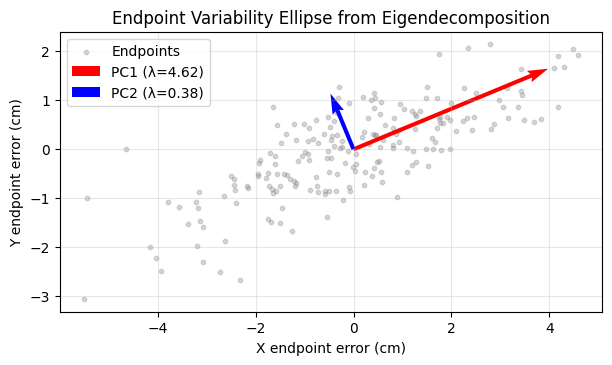

In [19]:
# ---- Visualize the variability ellipse ----

plt.figure(figsize=(7, 7))
plt.scatter(endpoints[:, 0], endpoints[:, 1], alpha=0.3, s=10, color='gray', label='Endpoints')

# Draw eigenvectors scaled by sqrt(eigenvalue) — these are the ellipse semi-axes
colors = ['red', 'blue']
for i in range(2):
    vec = eigenvectors[:, i] * np.sqrt(eigenvalues[i]) * 2  # Scale for visibility
    plt.quiver(0, 0, vec[0], vec[1], angles='xy', scale_units='xy', scale=1,
               color=colors[i], linewidth=2, label=f'PC{i+1} (λ={eigenvalues[i]:.2f})')

plt.gca().set_aspect('equal')
plt.xlabel('X endpoint error (cm)')
plt.ylabel('Y endpoint error (cm)')
plt.title('Endpoint Variability Ellipse from Eigendecomposition')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 12. Singular Value Decomposition (SVD) <a id='12'></a>

SVD decomposes **any** matrix (even non-square) into three components:

$$A = U \Sigma V^T$$

- $U$: left singular vectors (patterns in row space)
- $\Sigma$: singular values (importance of each component)
- $V^T$: right singular vectors (patterns in column space)

**Neuroscience use:** Extracting **muscle synergies** — low-dimensional patterns of muscle co-activation from a muscles × time EMG matrix.

In [20]:
# ---- SVD of a simulated EMG matrix ----
# Rows = 6 muscles, Columns = 100 time points

rng = np.random.default_rng(42)

# Create 2 underlying synergies (low-rank structure + noise)
synergy1 = np.array([0.9, 0.8, 0.1, 0.0, 0.2, 0.0])  # Flexor pattern
synergy2 = np.array([0.0, 0.1, 0.8, 0.9, 0.0, 0.7])  # Extensor pattern

activation1 = np.abs(np.sin(np.linspace(0, 2*np.pi, 100)))    # Time course 1
activation2 = np.abs(np.cos(np.linspace(0, 2*np.pi, 100)))    # Time course 2

# EMG = synergy1 * activation1 + synergy2 * activation2 + noise
EMG = (np.outer(synergy1, activation1) +
       np.outer(synergy2, activation2) +
       rng.normal(0, 0.05, (6, 100)))
EMG = np.clip(EMG, 0, None)  # EMG is non-negative

print(f"EMG matrix shape: {EMG.shape} (muscles × time)")

EMG matrix shape: (6, 100) (muscles × time)


In [21]:
# ---- Perform SVD ----

U, sigma, Vt = svd(EMG, full_matrices=False)

print(f"U shape:     {U.shape}")      # (6, 6) — muscle weightings
print(f"sigma shape: {sigma.shape}")   # (6,)   — singular values
print(f"Vt shape:    {Vt.shape}")      # (6, 100) — temporal patterns

# How much variance does each component explain?
variance_explained = (sigma ** 2) / np.sum(sigma ** 2) * 100
cumulative = np.cumsum(variance_explained)

print(f"\nVariance explained by each component:")
for i in range(6):
    print(f"  Component {i+1}: {variance_explained[i]:.1f}% (cumulative: {cumulative[i]:.1f}%)")

U shape:     (6, 6)
sigma shape: (6,)
Vt shape:    (6, 100)

Variance explained by each component:
  Component 1: 84.0% (cumulative: 84.0%)
  Component 2: 15.5% (cumulative: 99.5%)
  Component 3: 0.2% (cumulative: 99.7%)
  Component 4: 0.1% (cumulative: 99.8%)
  Component 5: 0.1% (cumulative: 99.9%)
  Component 6: 0.1% (cumulative: 100.0%)


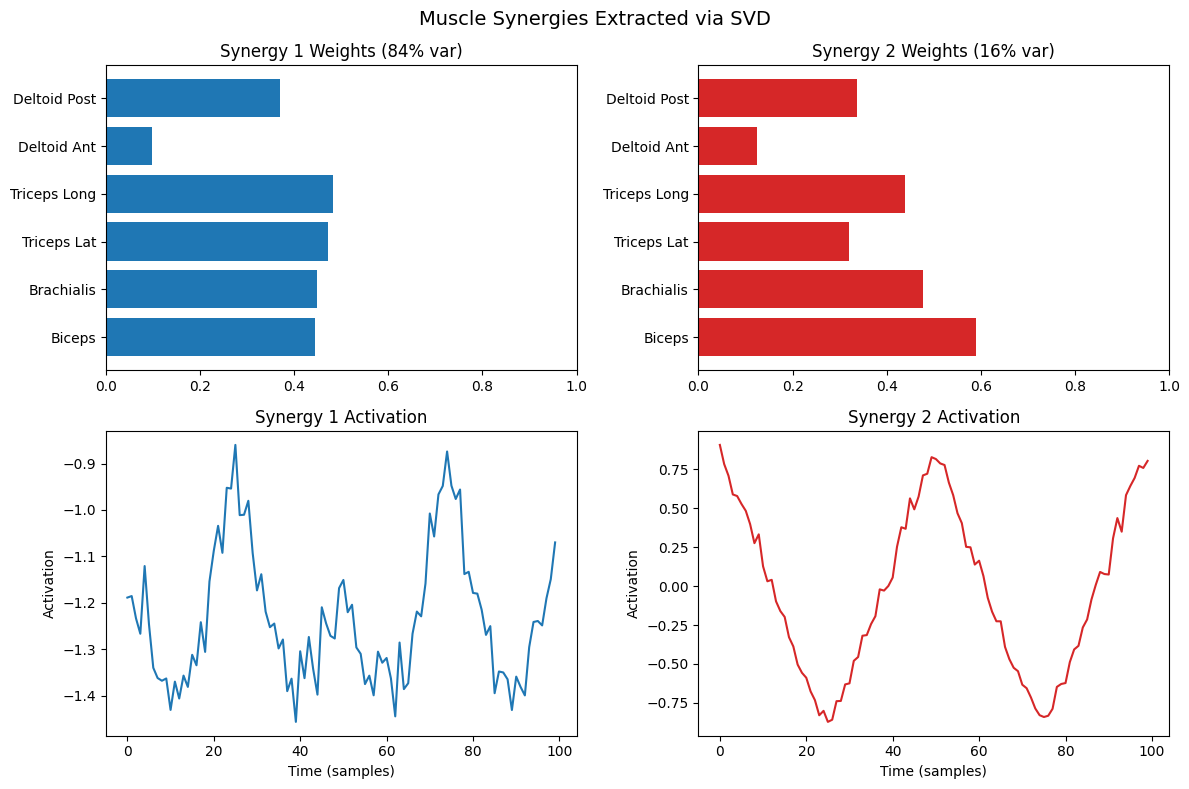

In [22]:
# ---- Visualize the first 2 synergies (from SVD) ----

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
muscle_names = ['Biceps', 'Brachialis', 'Triceps Lat', 'Triceps Long', 'Deltoid Ant', 'Deltoid Post']

# Synergy weights (columns of U)
for i in range(2):
    axes[0, i].barh(muscle_names, np.abs(U[:, i]), color=['tab:blue', 'tab:red'][i])
    axes[0, i].set_title(f'Synergy {i+1} Weights ({variance_explained[i]:.0f}% var)')
    axes[0, i].set_xlim(0, 1)

# Activation patterns (rows of Vt, scaled by sigma)
t = np.arange(100)
for i in range(2):
    axes[1, i].plot(t, sigma[i] * Vt[i, :], color=['tab:blue', 'tab:red'][i])
    axes[1, i].set_title(f'Synergy {i+1} Activation')
    axes[1, i].set_xlabel('Time (samples)')
    axes[1, i].set_ylabel('Activation')

plt.suptitle('Muscle Synergies Extracted via SVD', fontsize=14)
plt.tight_layout()
plt.show()

---
# Part IV — Applications in Sensorimotor Control

## 13. Least-Squares Regression <a id='13'></a>

Least-squares finds the vector $x$ that **minimizes** $\|Ax - b\|^2$. This is the foundation of model fitting — finding the parameters that best explain your data.

**Neuroscience use:** Fitting tuning curves, estimating preferred directions, linear regression of kinematic predictors.

In [23]:
# ---- Least-squares fit: reaction time ~ target distance + target width ----

rng = np.random.default_rng(42)
n = 50

# Generate synthetic data (Fitts's law inspired)
distance = rng.uniform(5, 30, n)       # Target distance (cm)
width = rng.uniform(0.5, 3.0, n)       # Target width (cm)
ID = np.log2(2 * distance / width)     # Index of difficulty
mt = 200 + 150 * ID + rng.normal(0, 30, n)  # Movement time (ms) with noise

# Set up the design matrix: [1, ID] for linear fit mt = a + b*ID
A = np.column_stack([np.ones(n), ID])  # (50, 2)
b = mt

# Solve using least squares
result = lstsq(A, b, rcond=None)
coeffs = result[0]
print(f"Fitts's Law fit: MT = {coeffs[0]:.1f} + {coeffs[1]:.1f} × ID")

# Also solve via the normal equations: x = (A^T A)^(-1) A^T b
coeffs_normal = inv(A.T @ A) @ A.T @ b
print(f"Normal equations: MT = {coeffs_normal[0]:.1f} + {coeffs_normal[1]:.1f} × ID")

Fitts's Law fit: MT = 189.3 + 151.8 × ID
Normal equations: MT = 189.3 + 151.8 × ID


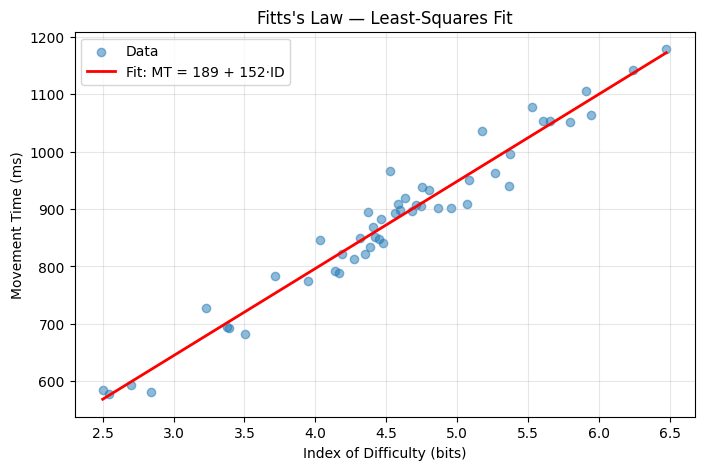

In [24]:
# ---- Plot the fit ----

ID_fit = np.linspace(ID.min(), ID.max(), 100)
MT_fit = coeffs[0] + coeffs[1] * ID_fit

plt.figure(figsize=(8, 5))
plt.scatter(ID, mt, alpha=0.5, label='Data')
plt.plot(ID_fit, MT_fit, 'r-', linewidth=2, label=f'Fit: MT = {coeffs[0]:.0f} + {coeffs[1]:.0f}·ID')
plt.xlabel('Index of Difficulty (bits)')
plt.ylabel('Movement Time (ms)')
plt.title("Fitts's Law — Least-Squares Fit")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

---
## 14. PCA — Dimensionality Reduction <a id='14'></a>

**Principal Component Analysis** finds the directions of maximum variance in your data. It's the eigendecomposition of the covariance matrix.

**Neuroscience use:** Reducing high-dimensional neural population activity to a few key dimensions, or finding the principal axes of kinematic variability.

In [25]:
# ---- PCA from scratch using eigendecomposition ----

# Generate 3-D kinematic data (e.g., x, y, z hand position across 200 reaches)
rng = np.random.default_rng(42)
n_reaches = 200

# The data has high variance along one axis and low along another
true_data = rng.multivariate_normal(
    mean=[15, 10, 5],
    cov=[[6, 2, 1],
         [2, 3, 0.5],
         [1, 0.5, 0.5]],
    size=n_reaches
)

# Step 1: Center the data (subtract the mean)
centered = true_data - true_data.mean(axis=0)

# Step 2: Compute covariance matrix
C = np.cov(centered, rowvar=False)  # (3, 3)
print(f"Covariance matrix:\n{C.round(2)}")

# Step 3: Eigendecomposition
eigenvalues, eigenvectors = eig(C)

# Sort by eigenvalue (largest first)
order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
eigenvectors = eigenvectors[:, order]

# Variance explained
var_explained = eigenvalues / eigenvalues.sum() * 100
print(f"\nVariance explained: {var_explained.round(1)}%")
print(f"Cumulative:         {np.cumsum(var_explained).round(1)}%")

Covariance matrix:
[[5.9  2.2  1.13]
 [2.2  3.09 0.54]
 [1.13 0.54 0.51]]

Variance explained: [77.3 19.9  2.9]%
Cumulative:         [ 77.3  97.1 100. ]%


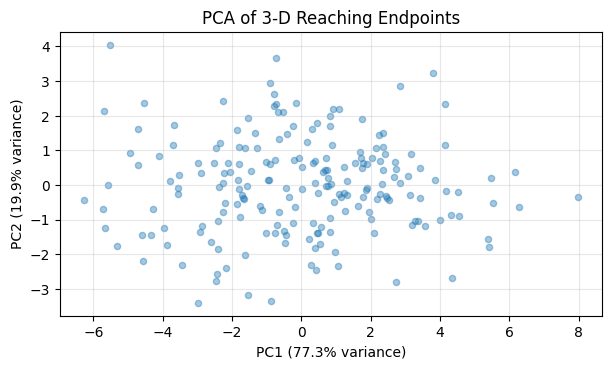

In [26]:
# ---- Project data onto the first 2 PCs ----

PC_scores = centered @ eigenvectors[:, :2]  # (200, 2)

plt.figure(figsize=(7, 6))
plt.scatter(PC_scores[:, 0], PC_scores[:, 1], alpha=0.4, s=20)
plt.xlabel(f'PC1 ({var_explained[0]:.1f}% variance)')
plt.ylabel(f'PC2 ({var_explained[1]:.1f}% variance)')
plt.title('PCA of 3-D Reaching Endpoints')
plt.gca().set_aspect('equal')
plt.grid(True, alpha=0.3)
plt.show()

---
## 15. State-Space Models — Linear Dynamical Systems <a id='15'></a>

A **state-space model** represents a dynamical system as:

$$\dot{x} = Ax + Bu$$
$$y = Cx$$

where $x$ is the state, $u$ is the input, $y$ is the output, and $A$, $B$, $C$ are matrices.

The **eigenvalues of $A$** determine system stability:
- All eigenvalues have **negative real part** → stable (decays to zero)
- Any eigenvalue has **positive real part** → unstable (blows up)
- **Imaginary parts** → oscillatory behavior

In [27]:
# ---- State-space model: mass-spring-damper ----
# State x = [position, velocity], Input u = external force
# dx/dt = Ax + Bu

m, b_damp, k = 1.0, 0.5, 4.0

A = np.array([[0, 1],
              [-k/m, -b_damp/m]])

B = np.array([[0],
              [1/m]])

print(f"System matrix A:\n{A}")
print(f"\nInput matrix B:\n{B}")

# Check stability via eigenvalues
evals = np.linalg.eigvals(A)
print(f"\nEigenvalues of A: {evals.round(4)}")
print(f"Real parts: {evals.real.round(4)}")
print(f"Stable? {np.all(evals.real < 0)}")
print(f"Oscillatory? {np.any(np.abs(evals.imag) > 1e-10)}")

# Natural frequency and damping ratio
omega_n = np.sqrt(k/m)
zeta = b_damp / (2 * np.sqrt(k * m))
print(f"\nNatural frequency: {omega_n:.2f} rad/s ({omega_n/(2*np.pi):.2f} Hz)")
print(f"Damping ratio:     {zeta:.3f} ({'underdamped' if zeta < 1 else 'overdamped'})")

System matrix A:
[[ 0.   1. ]
 [-4.  -0.5]]

Input matrix B:
[[0.]
 [1.]]

Eigenvalues of A: [-0.25+1.9843j -0.25-1.9843j]
Real parts: [-0.25 -0.25]
Stable? True
Oscillatory? True

Natural frequency: 2.00 rad/s (0.32 Hz)
Damping ratio:     0.125 (underdamped)


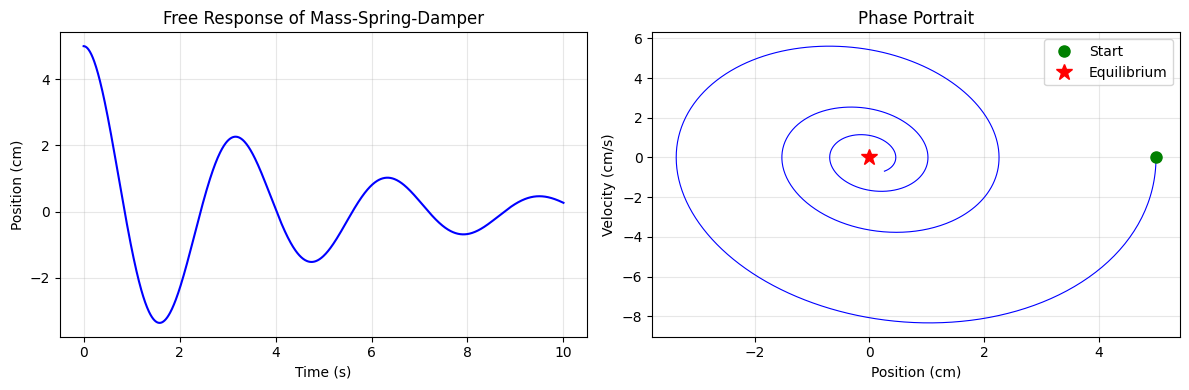

In [28]:
# ---- Simulate the state-space model using solve_ivp ----

from scipy.integrate import solve_ivp

def state_space_ode(t, x):
    u = 0.0  # No external force (free response)
    return A @ x + B.flatten() * u

x0 = [0.05, 0.0]  # Initial displacement of 5 cm
sol = solve_ivp(state_space_ode, (0, 10), x0, t_eval=np.linspace(0, 10, 1000))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(sol.t, sol.y[0] * 100, 'b-')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Position (cm)')
axes[0].set_title('Free Response of Mass-Spring-Damper')
axes[0].grid(True, alpha=0.3)

# Phase portrait: velocity vs position
axes[1].plot(sol.y[0] * 100, sol.y[1] * 100, 'b-', linewidth=0.8)
axes[1].plot(sol.y[0][0] * 100, sol.y[1][0] * 100, 'go', markersize=8, label='Start')
axes[1].plot(0, 0, 'r*', markersize=12, label='Equilibrium')
axes[1].set_xlabel('Position (cm)')
axes[1].set_ylabel('Velocity (cm/s)')
axes[1].set_title('Phase Portrait')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
# Part V — Practice

## 16. Exercises <a id='16'></a>

---

### Exercise 1: 2-Link Arm Forward Kinematics

For a planar 2-link arm with link lengths $L_1 = 30$ cm and $L_2 = 25$ cm:

$$x = L_1 \cos\theta_1 + L_2 \cos(\theta_1 + \theta_2)$$
$$y = L_1 \sin\theta_1 + L_2 \sin(\theta_1 + \theta_2)$$

1. Write a function `forward_kinematics(theta1, theta2, L1, L2)` that returns `(x, y)`.
2. Compute the hand position for $\theta_1 = 45°$, $\theta_2 = 90°$.
3. Plot the arm configuration (two line segments from shoulder to elbow to hand).
4. Compute the Jacobian numerically using finite differences and verify that $\dot{x} = J \dot{q}$.

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 2: Endpoint Variability Ellipse

1. Generate 300 endpoint positions from a 2-D Gaussian with mean `[20, 15]` and covariance `[[3, 1.5], [1.5, 2]]`.
2. Compute the eigenvalues and eigenvectors of the covariance matrix.
3. Plot the scatter with the principal axes drawn as arrows.
4. What is the ratio of variability along PC1 vs PC2?

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 3: Visuomotor Rotation Compensation

A 30° clockwise visuomotor rotation is applied. To compensate, the participant must plan a movement rotated 30° counterclockwise.

1. Create the 30° clockwise rotation matrix.
2. Create the 30° counterclockwise (compensatory) rotation matrix.
3. Verify that applying both rotations in sequence gives the identity.
4. Simulate a reaching trajectory that goes through the rotation and show that compensation recovers the straight path.

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 4: SVD for Muscle Synergies (Challenge)

1. Create a synthetic EMG matrix (8 muscles × 200 time points) from 3 underlying synergies plus noise.
2. Perform SVD.
3. Plot the scree plot (singular values) and determine how many synergies explain > 90% of the variance.
4. Reconstruct the EMG matrix using only the top $k$ synergies and compute the reconstruction error.

In [ ]:
# ---- YOUR CODE HERE ----


### Exercise 5: State-Space Stability Analysis (Challenge)

For the mass-spring-damper system $A = \begin{pmatrix} 0 & 1 \\ -k/m & -b/m \end{pmatrix}$:

1. Sweep the damping coefficient $b$ from 0 to 6 (with $m=1$, $k=4$).
2. For each $b$, compute the eigenvalues of $A$.
3. Plot the real and imaginary parts of the eigenvalues vs $b$.
4. Identify the critical damping point ($b_c = 2\sqrt{km}$) where eigenvalues transition from complex to real.

In [ ]:
# ---- YOUR CODE HERE ----


---
## 17. Summary & Further Reading <a id='17'></a>

### What You Learned

| Concept | NumPy function | Sensorimotor use |
|---|---|---|
| **Vector norm** | `np.linalg.norm(v)` | Distance, speed |
| **Dot product** | `np.dot(a, b)` or `a @ b` | Work, projection, similarity |
| **Cross product** | `np.cross(a, b)` | Torque from moment arm × force |
| **Matrix multiply** | `A @ B` | Transformations, $\dot{x} = J\dot{q}$ |
| **Rotation matrix** | Custom function | Coordinate transforms, visuomotor rotation |
| **Homogeneous transform** | Custom function | Combined rotation + translation |
| **Solve $Ax = b$** | `np.linalg.solve(A, b)` | Joint accelerations from torques |
| **Inverse** | `np.linalg.inv(A)` | When $A^{-1}$ is needed explicitly |
| **Pseudo-inverse** | `np.linalg.pinv(A)` | Redundant systems (more joints than DOFs) |
| **Determinant** | `np.linalg.det(A)` | Singularity detection |
| **Rank** | `np.linalg.matrix_rank(A)` | Dimensionality of synergy space |
| **Eigendecomposition** | `np.linalg.eig(A)` | Variability ellipses, stability analysis |
| **SVD** | `np.linalg.svd(A)` | Muscle synergies, dimensionality reduction |
| **Least squares** | `np.linalg.lstsq(A, b)` | Model fitting, regression |
| **PCA** | Eigen of covariance | Reduce dimensionality of neural/kinematic data |

### Further Reading

- [NumPy Linear Algebra](https://numpy.org/doc/stable/reference/routines.linalg.html) — complete API reference
- [3Blue1Brown — Essence of Linear Algebra](https://www.youtube.com/playlist?list=PLZHQObOWTQDPD3MizzM2xVFitgF8hE_ab) — outstanding visual intuition (free YouTube series)
- [Strang — *Introduction to Linear Algebra*](https://math.mit.edu/~gs/linearalgebra/) — the classic textbook
- [Shadmehr & Wise — *Computational Neurobiology of Reaching and Pointing*](https://www.shadmehrlab.org/book) — Jacobians, dynamics, and control
- [Tresch et al. (1999)](https://doi.org/10.1038/5765) — original muscle synergy paper using NMF
- [Churchland et al. (2012)](https://doi.org/10.1038/nature11129) — neural population dynamics via PCA/jPCA

### What's Next?

With linear algebra mastered, you can:
- **Build forward and inverse kinematics** models of multi-joint arms
- **Implement optimal feedback control** (LQR) using Riccati equations
- **Analyze neural population data** with PCA, factor analysis, and GPFA
- **Extract and interpret muscle synergies** from experimental EMG recordings

---

*Happy computing, and may your matrices always be full rank!*